In [26]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models('vllm') + ['siglip2_so400_16_512']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)

File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b

File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/bivlc.f
File not found:  /home

KeyError: 'year'

/tmp/ipykernel_1624934/953547125.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


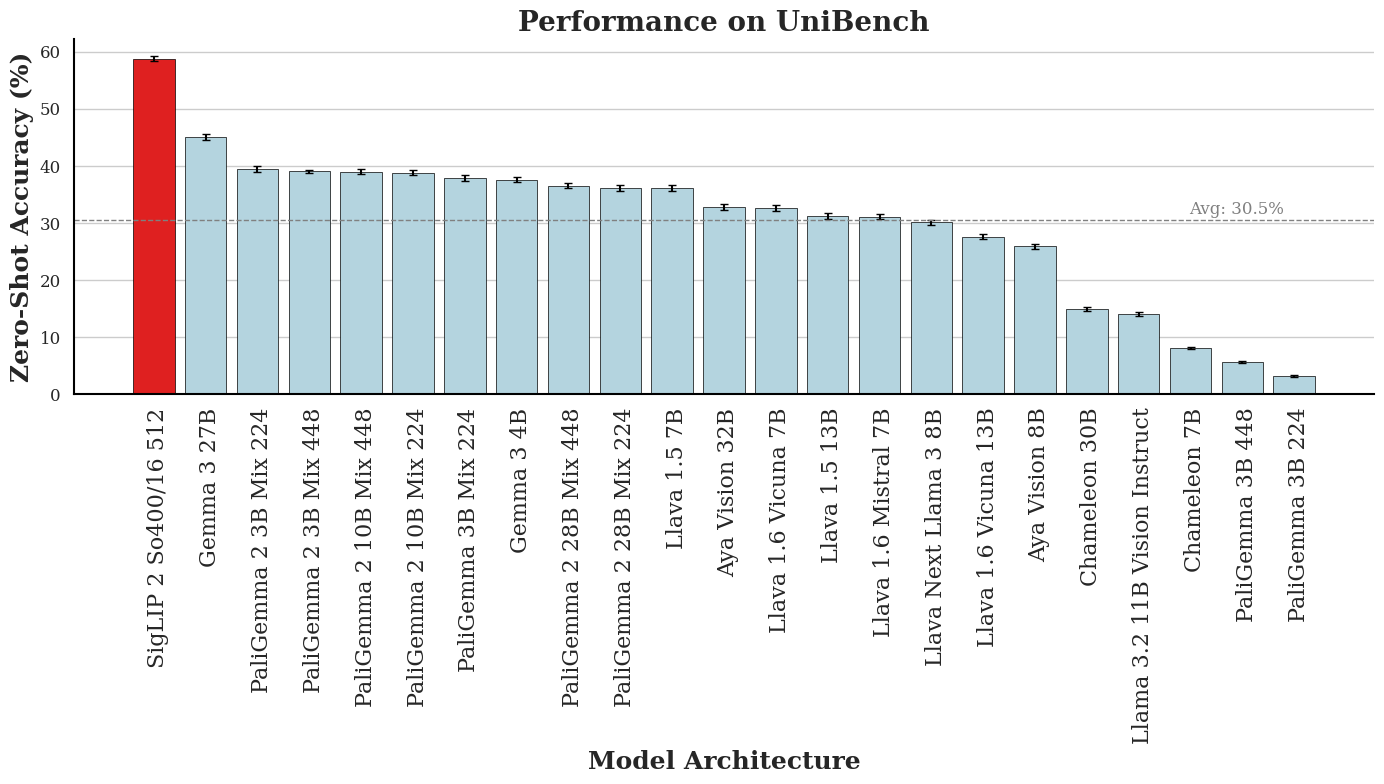

In [22]:
# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create colors: red for SigLIP, light blue for others
colors = ['red' if 'SigLIP' in name else 'lightblue' for name in sorted_models['model_name']]

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    palette=colors,
    edgecolor='black',
    linewidth=0.5,
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on UniBench', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.3 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

plt.show()


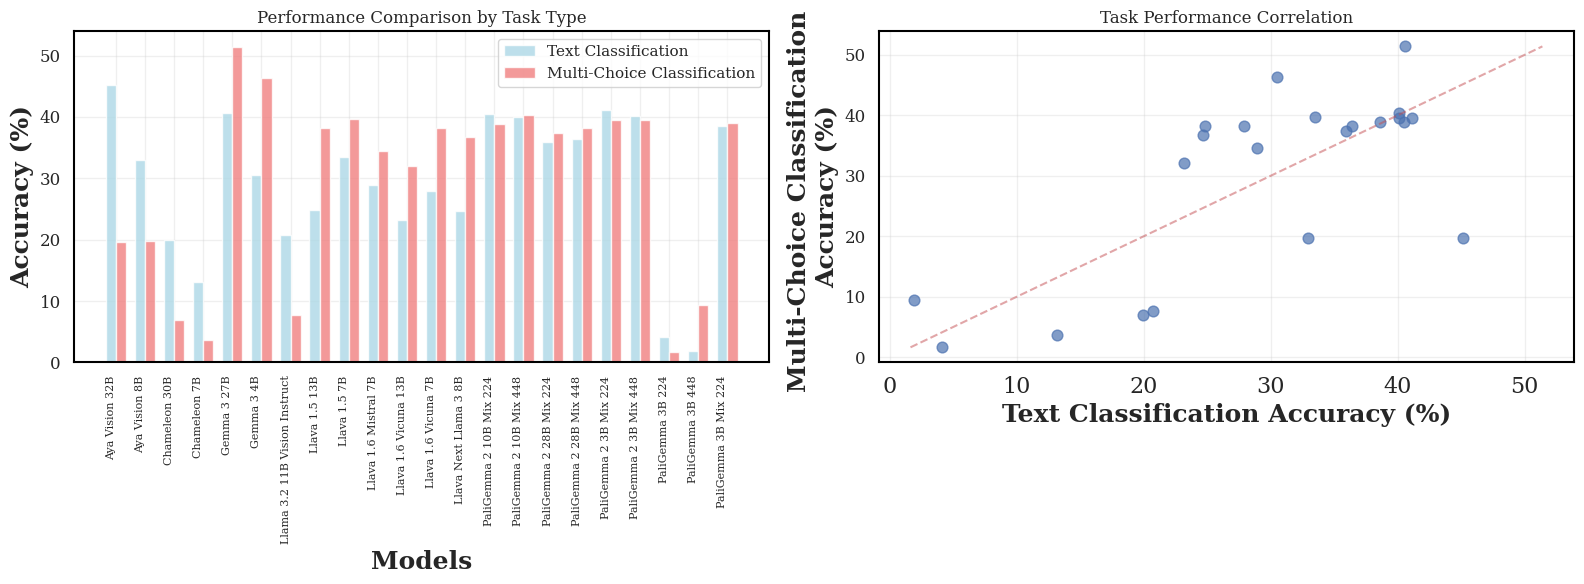

Task Performance Summary:
Text Classification - Mean: 29.3%, Std: 11.9%
Multi-Choice Classification - Mean: 29.9%, Std: 15.1%
Correlation: 0.726


In [23]:
# Filter data by task types
text_classification_data = results[results['task_name'] == 'text_classification']
multi_choice_data = results[results['task_name'] == 'multi_choice_classification']

# Compute performance for each task type
text_perf = text_classification_data.groupby('model_name')['correctness'].mean() * 100
multi_choice_perf = multi_choice_data.groupby('model_name')['correctness'].mean() * 100

# Create comparison dataframe
task_comparison = pd.DataFrame({
    'model_name': text_perf.index,
    'text_classification': text_perf.values,
    'multi_choice_classification': multi_choice_perf.reindex(text_perf.index).values
})

# Remove models with NaN values
task_comparison = task_comparison.dropna()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side-by-side comparison
x = range(len(task_comparison))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], task_comparison['text_classification'], 
               width, label='Text Classification', alpha=0.8, color='lightblue')
bars2 = ax1.bar([i + width/2 for i in x], task_comparison['multi_choice_classification'], 
               width, label='Multi-Choice Classification', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Performance Comparison by Task Type')
ax1.set_xticks(x)
ax1.set_xticklabels(task_comparison['model_name'], rotation=90, ha='right', fontsize=8)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Scatter plot showing correlation
ax2.scatter(task_comparison['text_classification'], task_comparison['multi_choice_classification'], 
           alpha=0.7, s=60)

# Add diagonal line for reference
min_val = min(task_comparison['text_classification'].min(), task_comparison['multi_choice_classification'].min())
max_val = max(task_comparison['text_classification'].max(), task_comparison['multi_choice_classification'].max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)

ax2.set_xlabel('Text Classification Accuracy (%)')
ax2.set_ylabel('Multi-Choice Classification \nAccuracy (%)')
ax2.set_title('Task Performance Correlation')
ax2.grid(True, alpha=0.3)

# Add model labels to scatter points
# for i, model in enumerate(task_comparison['model_name']):
#     ax2.annotate(model.split()[-1], 
#                 (task_comparison['text_classification'].iloc[i], 
#                  task_comparison['multi_choice_classification'].iloc[i]),
#                 xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Task Performance Summary:")
print(f"Text Classification - Mean: {task_comparison['text_classification'].mean():.1f}%, Std: {task_comparison['text_classification'].std():.1f}%")
print(f"Multi-Choice Classification - Mean: {task_comparison['multi_choice_classification'].mean():.1f}%, Std: {task_comparison['multi_choice_classification'].std():.1f}%")
print(f"Correlation: {task_comparison['text_classification'].corr(task_comparison['multi_choice_classification']):.3f}")


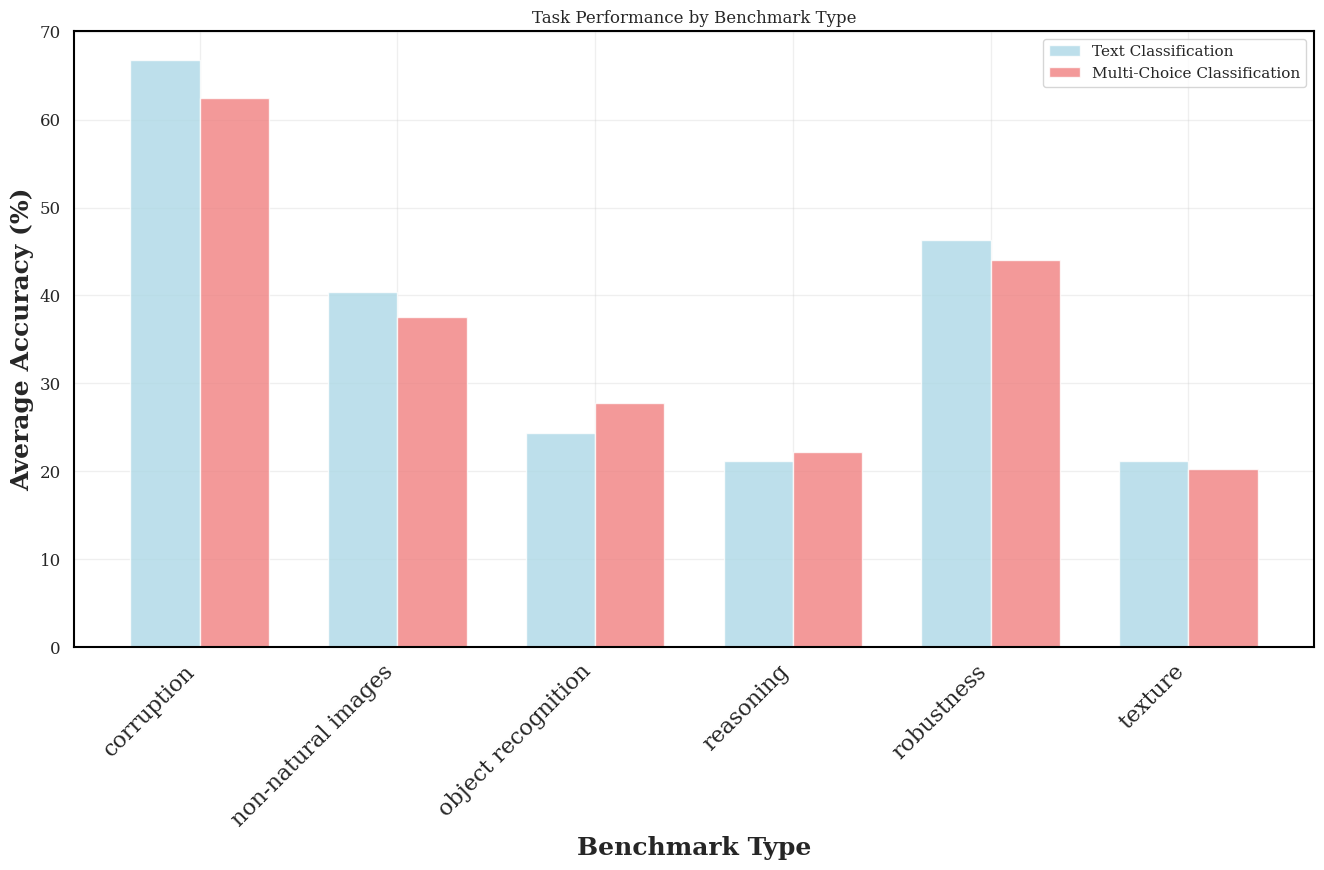

In [24]:
# Group by benchmark type and task type to show differences
benchmark_task_comparison = results.groupby(['benchmark_type', 'task_name'])['correctness'].agg(['mean', 'count']).reset_index()
benchmark_task_comparison['mean'] = benchmark_task_comparison['mean'] * 100

# Pivot to compare task types side by side
pivot_comparison = benchmark_task_comparison.pivot(index='benchmark_type', columns='task_name', values='mean')
pivot_counts = benchmark_task_comparison.pivot(index='benchmark_type', columns='task_name', values='count')

# Create visualization
fig, ax1 = plt.subplots(1, figsize=(16, 8))

# Plot 1: Performance comparison by benchmark type
benchmark_types = pivot_comparison.index
x_pos = range(len(benchmark_types))
width = 0.35

if 'text_classification' in pivot_comparison.columns:
    text_scores = pivot_comparison['text_classification'].fillna(0)
    ax1.bar([x - width/2 for x in x_pos], text_scores, width, 
           label='Text Classification', alpha=0.8, color='lightblue')

if 'multi_choice_classification' in pivot_comparison.columns:
    mc_scores = pivot_comparison['multi_choice_classification'].fillna(0)
    ax1.bar([x + width/2 for x in x_pos], mc_scores, width, 
           label='Multi-Choice Classification', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Benchmark Type')
ax1.set_ylabel('Average Accuracy (%)')
ax1.set_title('Task Performance by Benchmark Type')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(benchmark_types, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)



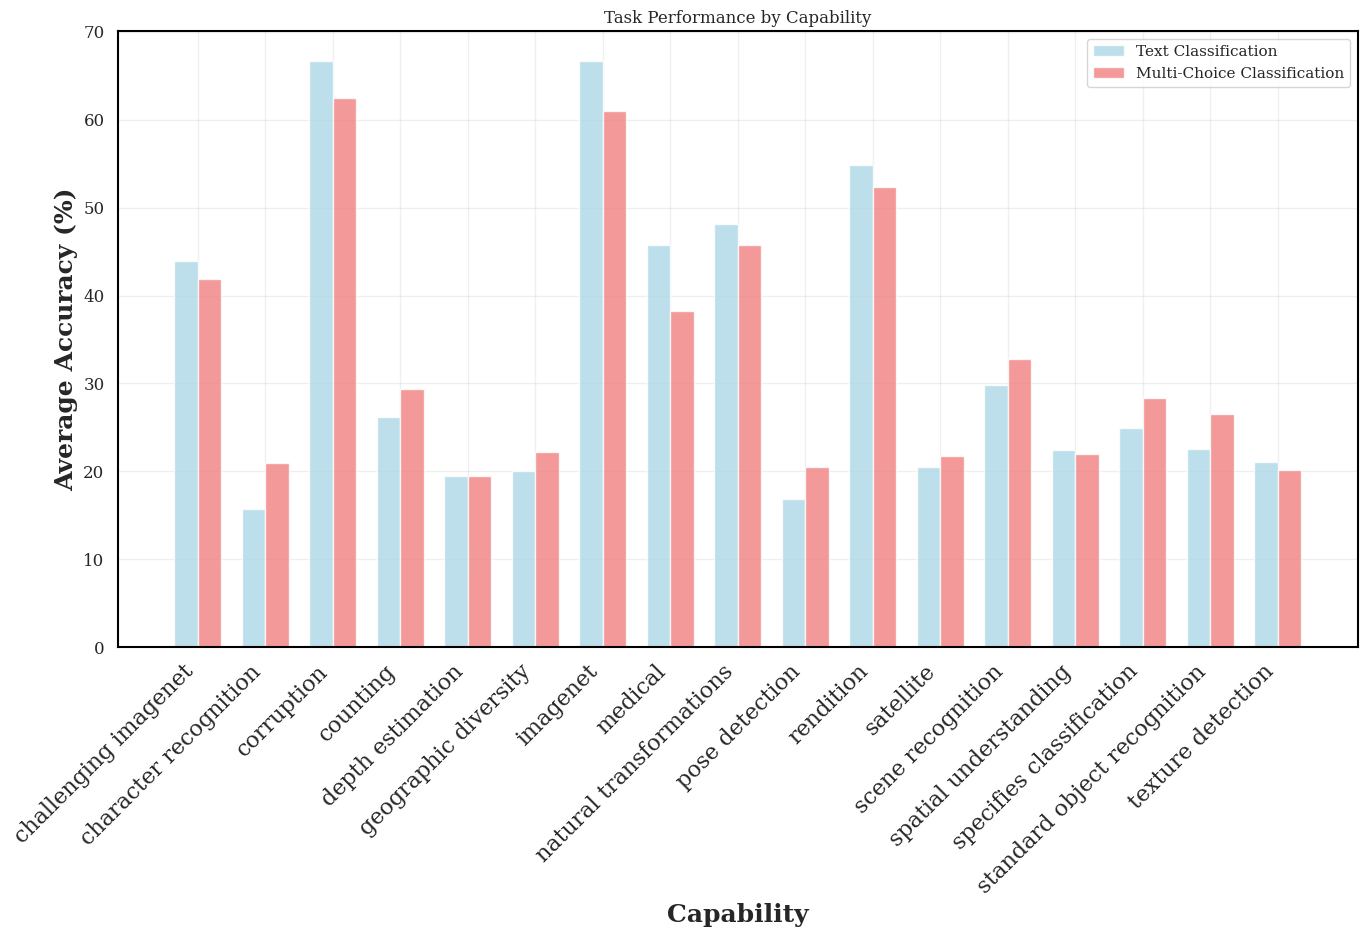

In [25]:
# Group by capability and task type to show differences
benchmark_task_comparison = results.groupby(['capability', 'task_name'])['correctness'].agg(['mean', 'count']).reset_index()
benchmark_task_comparison['mean'] = benchmark_task_comparison['mean'] * 100

# Pivot to compare task types side by side
pivot_comparison = benchmark_task_comparison.pivot(index='capability', columns='task_name', values='mean')
pivot_counts = benchmark_task_comparison.pivot(index='capability', columns='task_name', values='count')

# Create visualization
fig, ax1 = plt.subplots(1, figsize=(16, 8))

# Plot 1: Performance comparison by capability
capability_types = pivot_comparison.index
x_pos = range(len(capability_types))
width = 0.35

if 'text_classification' in pivot_comparison.columns:
    text_scores = pivot_comparison['text_classification'].fillna(0)
    ax1.bar([x - width/2 for x in x_pos], text_scores, width, 
           label='Text Classification', alpha=0.8, color='lightblue')

if 'multi_choice_classification' in pivot_comparison.columns:
    mc_scores = pivot_comparison['multi_choice_classification'].fillna(0)
    ax1.bar([x + width/2 for x in x_pos], mc_scores, width, 
           label='Multi-Choice Classification', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Capability')
ax1.set_ylabel('Average Accuracy (%)')
ax1.set_title('Task Performance by Capability')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(capability_types, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)


In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models('vllm')

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)
model_mappings = get_model_mappings('year')
results['year'] = results["model_name"].map(model_mappings)
model_mappings = get_model_mappings('month')
results['month'] = results["model_name"].map(model_mappings)

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Custom font sizes and styling
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 20
LINE_WIDTH = 4
MARKER_SIZE = 12

# Create a time column combining year and month 
results['time'] = results['year'].astype(str) + '-' + results['month'].astype(str).str.zfill(2)

# Calculate average performance per model by time
time_perf = results.groupby(['model_name'])['correctness'].mean().reset_index()

# Join with time information (taking first occurrence of each model)
model_times = results.drop_duplicates('model_name')[['model_name', 'time', 'year', 'month']]
time_perf = time_perf.merge(model_times, on='model_name')

# Convert performance to percentage
time_perf['performance'] = time_perf['correctness'] * 100

# Sort by time
time_perf['time_sort'] = time_perf['year'] * 100 + time_perf['month'].astype(int)
time_perf = time_perf.sort_values('time_sort')
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Custom font sizes and styling
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 20

# Apply theme
sns.set_theme(style="white", font_scale=1.5)

# Create figure
plt.figure(figsize=(12, 8))

# Plot violin plot
ax = sns.violinplot(
    data=time_perf,
    x='year',
    y='performance',
    inner="quartile",
    linewidth=2,
    cut=0,
    scale='width',
    palette=["#3b76af"] * time_perf['year'].nunique()
)

# Axis labels
ax.set_xlabel("Release Year", fontsize=LABEL_FONT_SIZE, labelpad=12)
ax.set_ylabel("Model Zero-Shot Accuracy (%)", fontsize=LABEL_FONT_SIZE, labelpad=12)

# Ticks formatting
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE, length=6, width=1)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)

# Style adjustments
sns.despine(trim=True)
ax.grid(False)

# Tight layout and save
plt.tight_layout()
# plt.savefig("imagenet_violin_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()



IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer